In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
!pip install pandas openpyxl

In [ ]:
data_area_harvested = pd.read_excel('/content/drive/MyDrive/NU work/Cotton/AREA_HARVESTED.xlsx', usecols=['location_desc', 'year', 'Value'])
data_area_planted = pd.read_excel('/content/drive/MyDrive/NU work/Cotton/AREA_PLANTED.xlsx', usecols=['location_desc', 'year', 'Value'])
data_yield = pd.read_excel('/content/drive/MyDrive/NU work/Cotton/YIELD.xlsx', usecols=['location_desc', 'year', 'Value'])

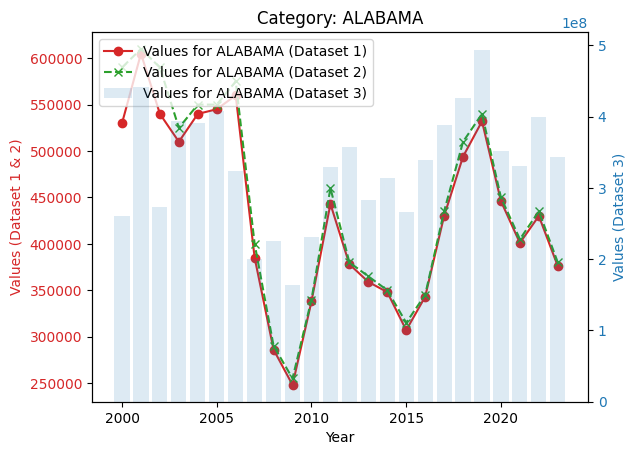

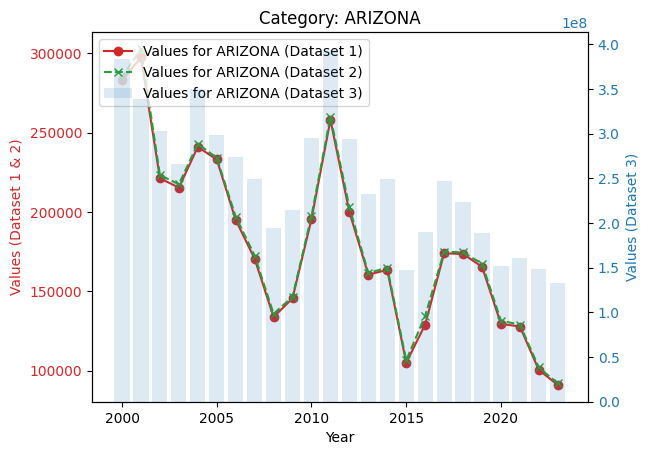

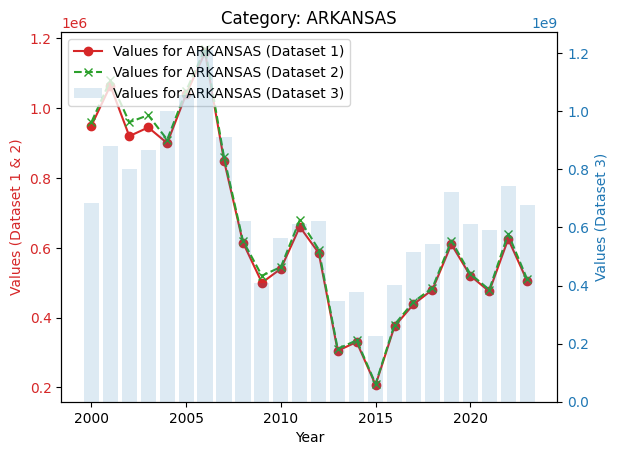

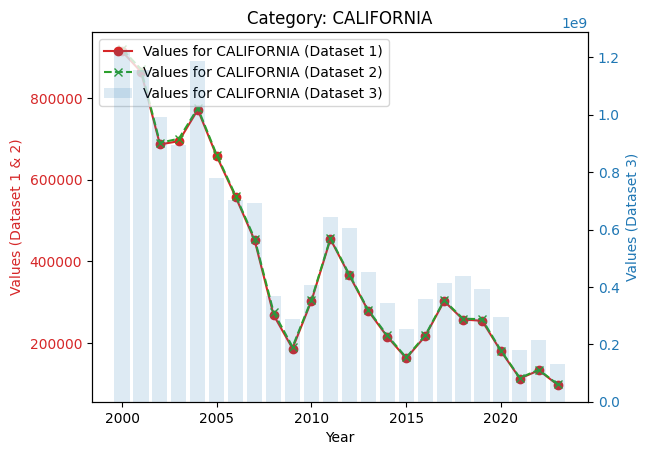

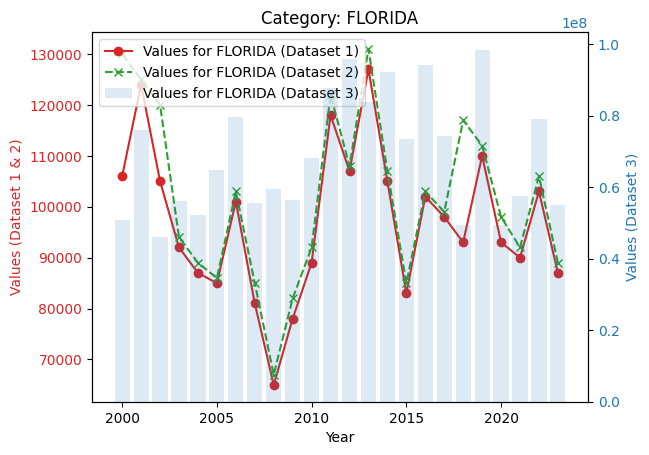

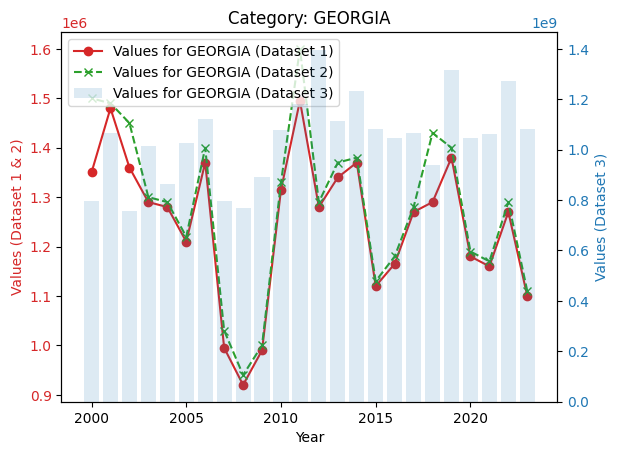

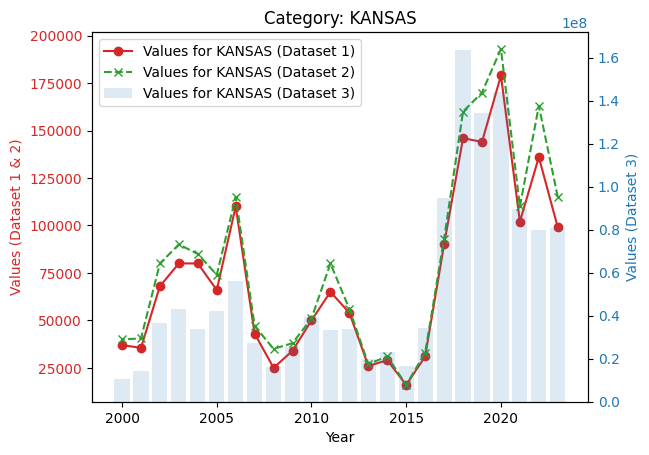

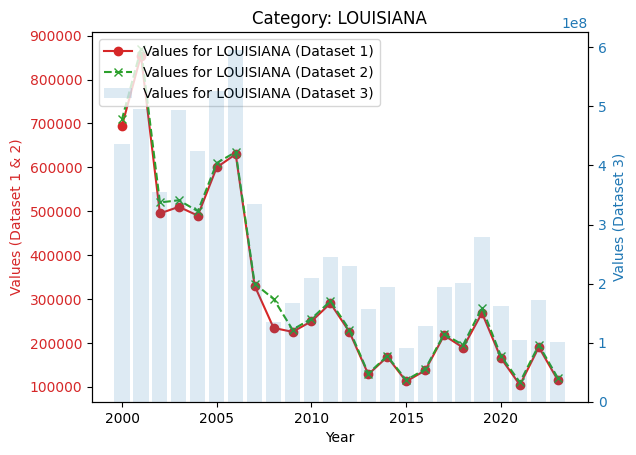

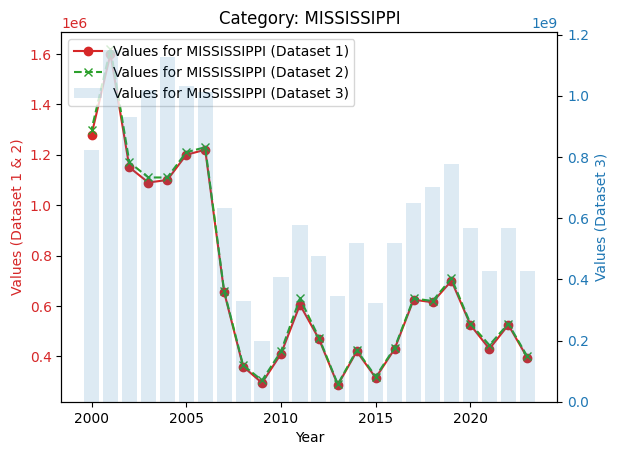

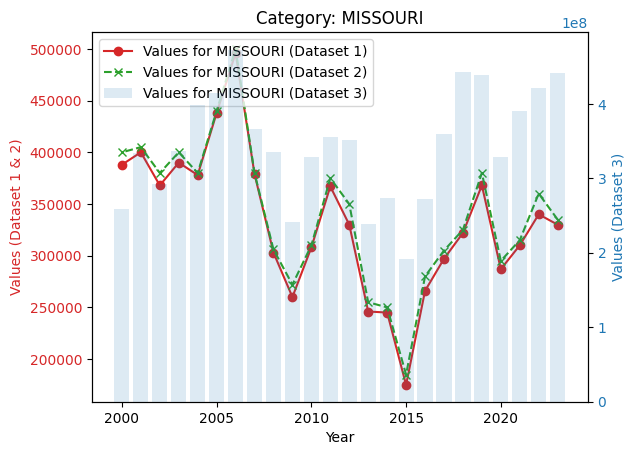

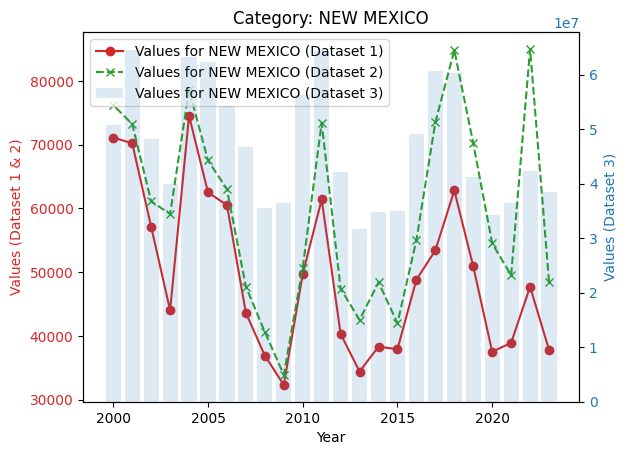

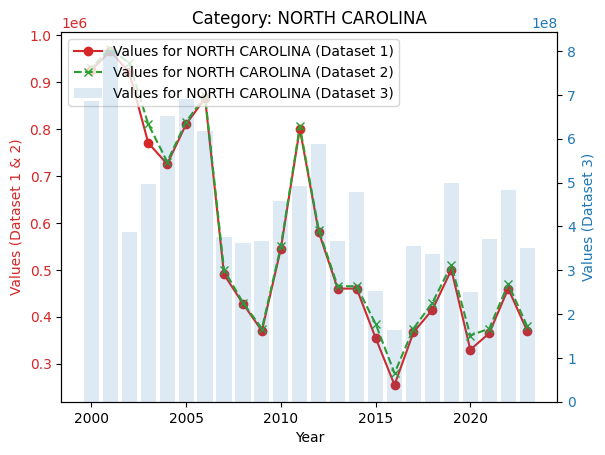

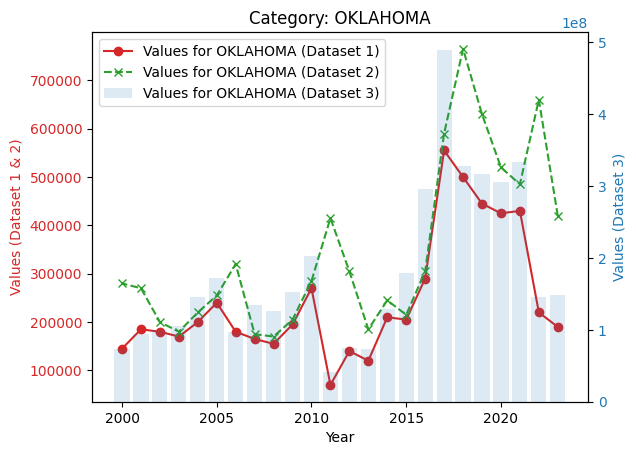

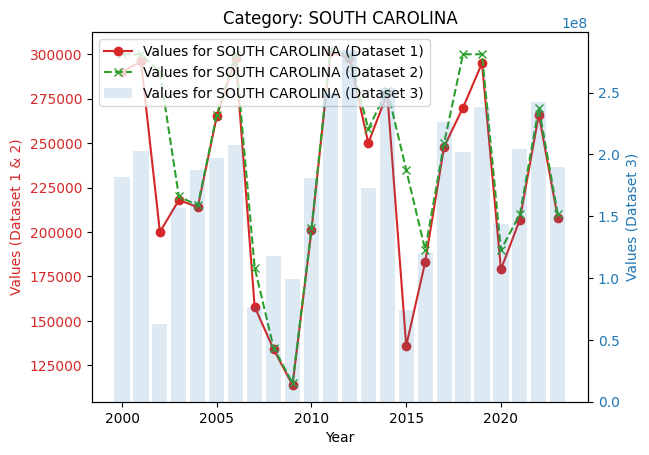

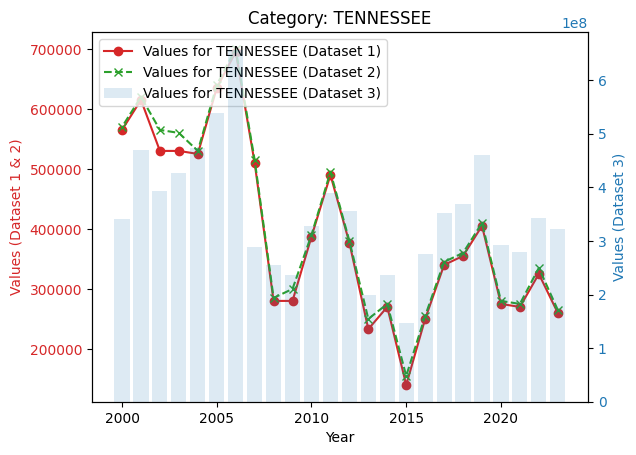

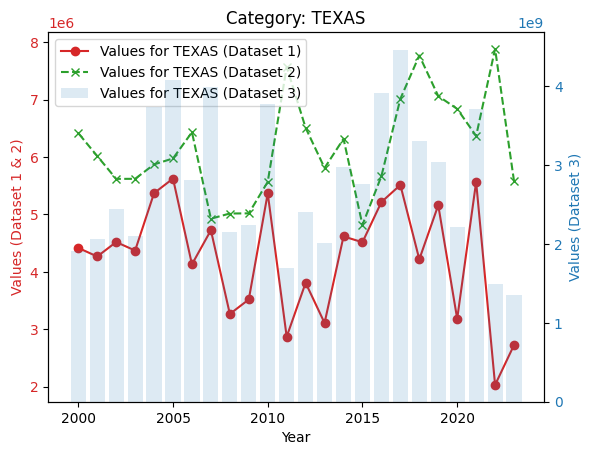

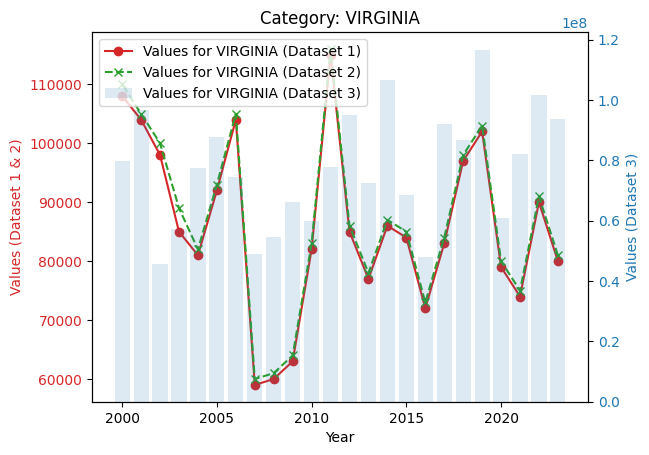

[array([376000., 430000., 401000., 446000., 532000., 494000., 430000.,
       343000., 307000., 348000., 359000., 378000., 443000., 338000.,
       248000., 286000., 385000., 560000., 545000., 540000., 510000.,
       540000., 605000., 530000.]), array([ 91000., 100400., 127800., 129500., 165500., 173500., 174000.,
       129000., 105000., 163500., 160500., 200000., 258000., 195500.,
       145600., 133800., 170500., 195000., 233100., 241000., 215400.,
       221200., 297500., 282900.]), array([ 505000.,  625000.,  475000.,  520000.,  610000.,  480000.,
        438000.,  375000.,  207000.,  330000.,  305000.,  585000.,
        660000.,  540000.,  500000.,  615000.,  850000., 1160000.,
       1040000.,  900000.,  945000.,  920000., 1065000.,  950000.]), array([ 96800., 132500., 112500., 179500., 254000., 257000., 302000.,
       216000., 162000., 215000., 278000., 365000., 454000., 303000.,
       186000., 268000., 451000., 557000., 657000., 771000., 694000.,
       686000., 864000., 91

In [ ]:
# print(data_area_harvested.head())
grouped_data_area_harvested = data_area_harvested.groupby('location_desc')
grouped_data_area_planted = data_area_planted.groupby('location_desc')
grouped_data_yield = data_yield.groupby('location_desc')

def plot_function(grouped1, grouped2, grouped3):
    # Ensure the group names match and are in the same order for all groupby objects
    keys1 = grouped1.groups.keys()
    keys2 = grouped2.groups.keys()
    keys3 = grouped3.groups.keys()

    common_keys = sorted(set(keys1) & set(keys2) & set(keys3))

    # Initialize lists to store sums for each group
    harvested_area_sums = []
    planted_area_sums = []
    yield_sums = []
    categories = []  # To keep track of the keys/categories

    for key in common_keys:
        group_df1 = grouped1.get_group(key)
        group_df2 = grouped2.get_group(key)
        group_df3 = grouped3.get_group(key)

        # Create a figure and a primary y-axis
        fig, ax1 = plt.subplots()
        plt.title(f"Category: {key}")

        color1 = 'tab:red'
        # Plot from the first group on the primary y-axis
        ax1.plot(group_df1['year'], group_df1['Value'].str.replace(',', '').astype(float),
                 marker='o', linestyle='-', color=color1, label=f"Values for {key} (Dataset 1)")


        color2 = 'tab:green'
        # Plot from the second group on the primary y-axis
        ax1.plot(group_df2['year'], group_df2['Value'].str.replace(',', '').astype(float),
                 marker='x', linestyle='--', color=color2, label=f"Values for {key} (Dataset 2)")

        ax1.set_xlabel('Year')
        ax1.set_ylabel('Values (Dataset 1 & 2)', color=color1)
        ax1.tick_params(axis='y', labelcolor=color1)

        # Create a secondary y-axis for the third group
        ax2 = ax1.twinx()
        color3 = 'tab:blue'
        # Plot from the third group on the secondary y-axis
        ax2.bar(group_df3['year'], group_df1['Value'].str.replace(',', '').astype(float) * group_df3['Value'].str.replace(',', '').astype(float),
                color=color3, alpha=0.15, label=f"Values for {key} (Dataset 3)")
        ax2.set_ylabel('Values (Dataset 3)', color=color3)
        ax2.tick_params(axis='y', labelcolor=color3)

        categories.append(key)
        harvested_area_sums.append(np.array(group_df1['Value'].str.replace(',', '').astype(float)))
        planted_area_sums.append(np.array(group_df2['Value'].str.replace(',', '').astype(float)))
        yield_sums.append(np.array(group_df3['Value'].str.replace(',', '').astype(float)))

        # Handling the legends for both ax1 and ax2
        # Get handles and labels for each plot
        handles1, labels1 = ax1.get_legend_handles_labels()
        handles2, labels2 = ax2.get_legend_handles_labels()
        # Combine handles and labels for the legend
        handles = handles1 + handles2
        labels = labels1 + labels2

        # Place a legend on the plot
        ax1.legend(handles, labels, loc='upper left')

        plt.show()
    print(harvested_area_sums)
    df_harvested = pd.DataFrame(harvested_area_sums, columns=group_df1['year'])
    df_planted = pd.DataFrame(planted_area_sums, columns=group_df2['year'])
    df_yield = pd.DataFrame(yield_sums, columns=group_df3['year']).reset_index(drop=True)
    df_categories = pd.DataFrame({'Category': categories})

    print(df_categories.shape, df_planted)
    df_summary = pd.concat([df_categories, df_harvested, df_planted, df_yield], axis=1)

    df_harvested = pd.concat([df_categories, df_harvested], axis=1)
    df_planted = pd.concat([df_categories, df_planted], axis=1)
    df_yield = pd.concat([df_categories, df_yield], axis=1)

    return(df_harvested,df_planted,df_yield, df_summary)

df_harvested,df_planted,df_yield, df_summary = plot_function(grouped_data_area_harvested,grouped_data_area_planted, grouped_data_yield)




In [ ]:

def data_process(data):
  grouped_data = data.groupby('location_desc')
  keys = sorted(grouped_data.groups.keys())

  # Initialize lists to store
  data_sums = []
  categories = []
  for key in keys:
    grouped_subdata = grouped_data.get_group(key)
    categories.append(key)
    data_sums.append(np.array(grouped_subdata['Value'].str.replace(',', '').astype(float)))

  df_grouped = pd.DataFrame(data_sums, columns=grouped_subdata['year'])
  df_categories = pd.DataFrame({'Category': categories})
  df = pd.concat([df_categories, df_grouped], axis=1)
  return (df)


data_production = pd.read_excel('/content/drive/MyDrive/NU work/Cotton/SURVEY_GE2000_PRODUCTIONS.xlsx', usecols=['location_desc', 'year', 'Value'])
df_production = data_process(data_production)


In [ ]:
# process all the census data for irrigated area and overall area

data_census_irrigated_harvested = pd.read_excel('/content/drive/MyDrive/NU work/Cotton/CENSUS_GE1997_IRRIGATED_AREA_HARVESTED.xlsx', usecols=['location_desc', 'year', 'Value'])
df = data_census_irrigated_harvested

# Convert the 'Value' column to a numeric type, removing commas
df['Value'] = pd.to_numeric(df['Value'].str.replace(',', ''), errors='coerce')
# Pivot the table to get states as index, years as columns, and values as cell values
df_pivoted = df.pivot_table(index='location_desc', columns='year', values='Value', aggfunc='first')
# Fill missing years from 1997 to 2023 if they are not present
all_years = list(range(1997, 2024))

df_pivoted = df_pivoted.reindex(columns=all_years, fill_value=None).interpolate(method='linear', axis=1, limit_direction='both')
df_pivoted.drop('ILLINOIS', inplace=True)

df_census_irrigated_harvested = df_pivoted
print(df_census_irrigated_harvested)
# df_census_irrigated_harvested.to_excel('/content/drive/MyDrive/NU work/Cotton/test_census_irrigated_harvested.xlsx')


data_census_harvested = pd.read_excel('/content/drive/MyDrive/NU work/Cotton/CENSUS_GE1997_AREA_HARVESTED.xlsx', usecols=['location_desc', 'year', 'Value'])
df = data_census_harvested

df['Value'] = pd.to_numeric(df['Value'].str.replace(',', ''), errors='coerce')
# Pivot the table to get states as index, years as columns, and values as cell values
df_pivoted = df.pivot_table(index='location_desc', columns='year', values='Value', aggfunc='first')
# Fill missing years from 1997 to 2023 if they are not present
all_years = list(range(1997, 2024))

df_pivoted = df_pivoted.reindex(columns=all_years, fill_value=None).interpolate(method='linear', axis=1, limit_direction='both')
# df_pivoted.drop('ILLINOIS', inplace=True)

df_census_harvested = df_pivoted
print(df_census_harvested)





year                 1997       1998       1999       2000       2001  \
location_desc                                                           
ALABAMA           13306.0    17175.6    21045.2    24914.8    28784.4   
ARIZONA          339936.0   316493.2   293050.4   269607.6   246164.8   
ARKANSAS         608335.0   629062.0   649789.0   670516.0   691243.0   
CALIFORNIA      1043208.0   973497.0   903786.0   834075.0   764364.0   
FLORIDA            8491.0     8491.0     8491.0     8491.0     8491.0   
GEORGIA          294577.0   301234.8   307892.6   314550.4   321208.2   
KANSAS            24990.0    24990.0    24990.0    24990.0    24990.0   
LOUISIANA        164711.0   162103.0   159495.0   156887.0   154279.0   
MISSISSIPPI      322371.0   338160.8   353950.6   369740.4   385530.2   
MISSOURI         139640.0   152874.4   166108.8   179343.2   192577.6   
NEW MEXICO        73659.0    69536.2    65413.4    61290.6    57167.8   
NORTH CAROLINA    12234.0    14522.0    16810.0    

In [ ]:
data_water_applied = pd.read_excel('/content/drive/MyDrive/NU work/Cotton/CENSUS_GE1997_WATER_APPLIED.xlsx', usecols=['location_desc', 'year', 'Value'])
df = data_water_applied

df['Value'] = pd.to_numeric(df['Value'].str.replace(',', ''), errors='coerce')
# Pivot the table to get states as index, years as columns, and values as cell values
df_pivoted = df.pivot_table(index='location_desc', columns='year', values='Value', aggfunc='first')
# Fill missing years from 1997 to 2023 if they are not present
all_years = list(range(1997, 2024))

df_pivoted = df_pivoted.reindex(columns=all_years, fill_value=None).interpolate(method='linear', axis=1, limit_direction='both')
df_pivoted.drop('ILLINOIS', inplace=True)

df_water_applied = df_pivoted
print(df_water_applied)


file_path = '/content/drive/MyDrive/NU work/Cotton/Python outputs/PROCESS_GE2000_BASE.xlsx'

# Create a Pandas Excel writer using openpyxl as the engine
with pd.ExcelWriter(file_path, engine='openpyxl') as writer:
    # Write each DataFrame to a different sheet
    df_harvested.to_excel(writer, sheet_name='harvested area')
    df_planted.to_excel(writer, sheet_name='planted area')
    df_yield.to_excel(writer, sheet_name='yield')
    df_production.to_excel(writer, sheet_name='production')
    df_census_irrigated_harvested.to_excel(writer, sheet_name='census irrigated harvested')
    df_census_harvested.to_excel(writer, sheet_name='census overall harvested')
    df_water_applied.to_excel(writer, sheet_name='water applied')





year            1997  1998  1999  2000  2001  2002  2003  2004  2005  2006  \
location_desc                                                                
ALABAMA          0.4   0.4   0.4   0.4   0.4   0.4   0.4   0.4   0.4   0.4   
ARIZONA          4.5   4.5   4.5   4.5   4.5   4.5   4.5   4.5   4.5   4.5   
ARKANSAS         0.9   0.9   0.9   0.9   0.9   0.9   0.9   0.9   0.9   0.9   
CALIFORNIA       2.9   2.9   2.9   2.9   2.9   2.9   2.9   2.9   2.9   2.9   
FLORIDA          0.6   0.6   0.6   0.6   0.6   0.6   0.6   0.6   0.6   0.6   
GEORGIA          0.5   0.5   0.5   0.5   0.5   0.5   0.5   0.5   0.5   0.5   
KANSAS           0.8   0.8   0.8   0.8   0.8   0.8   0.8   0.8   0.8   0.8   
LOUISIANA        0.6   0.6   0.6   0.6   0.6   0.6   0.6   0.6   0.6   0.6   
MISSISSIPPI      0.8   0.8   0.8   0.8   0.8   0.8   0.8   0.8   0.8   0.8   
MISSOURI         1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   
NEW MEXICO       1.7   1.7   1.7   1.7   1.7   1.7   1.7   1.7  

In [ ]:
data_applications  = pd.read_excel('/content/drive/MyDrive/NU work/Cotton/SURVEY_GE2000_APPLICATIONS.xlsx', usecols=[9, 11, 12, 17, 31, 38, 39])

# Define the list of values to keep
values_to_keep = ["CHEMICAL, FUNGICIDE: (TOTAL)", "CHEMICAL, HERBICIDE: (TOTAL)",
                  "CHEMICAL, INSECTICIDE: (TOTAL)", "CHEMICAL, OTHER: (TOTAL)",
                  "FERTILIZER: (NITROGEN)", "FERTILIZER: (PHOSPHATE)",
                  "FERTILIZER: (POTASH)", "FERTILIZER: (SULFUR)"]

filtered_df_app = data_applications[data_applications['domaincat_desc'].isin(values_to_keep)]
df = filtered_df_app.sort_values(by=["year","state_name", "domaincat_desc"], ascending=True)[['year','state_name','domaincat_desc', 'Value']]


def sanitize_sheet_name(name):
    """Sanitize the sheet name by removing invalid characters and limiting the length."""
    invalid_chars = '[]:*?/\\'
    for char in invalid_chars:
        name = name.replace(char, '')
    return name[:31]  # Excel sheet name limit

def reformat_excel(df, output_file_path):
    """Reformat the Excel file structure as specified."""
    # Load the original Excel file
    # df = pd.read_excel(input_file_path)

    # Identify unique domain category descriptions
    df['Value'] = pd.to_numeric(df['Value'].replace(' (D)', np.nan).str.replace(',', ''), errors='coerce')
    domain_categories = df['domaincat_desc'].unique()

    # Create a new Excel file with the reformatted structure
    with pd.ExcelWriter(output_file_path, engine='openpyxl') as writer:
        for domain in domain_categories:
            # Filter dataframe for the current domain
            df_domain = df[df['domaincat_desc'] == domain]

            # Pivot the table to get 'year' as columns and 'state_name' as rows
            pivot_table = df_domain.pivot_table(index='state_name', columns='year', values='Value', aggfunc='first')

            # Write each domain's pivot table to a separate sheet
            sanitized_sheet_name = sanitize_sheet_name(domain)
            pivot_table.to_excel(writer, sheet_name=sanitized_sheet_name)

# Specify the input and output file paths
output_file_path = '/content/drive/MyDrive/NU work/Cotton/PROCESS_GE2000_APPLICATIONS.xlsx'

# Call the function with the specified file paths
reformat_excel(df, output_file_path)


